# Call Report Fragility Panel (v2)

In [55]:
import csv
import gc
import io
import logging
import random
import re
import tempfile
import time
import warnings
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path
from urllib.parse import urljoin

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)


## Configuration
- `ASSET_SCALE = 1_000` assumes Call Report dollar amounts are reported in **thousands**.
- Regional definition defaults to **$10bn to $250bn** in total assets (configurable).

In [ ]:
# ---------- User-configurable settings ----------
ZIP_FILENAME = 'data/Input/FFIEC_Raw/FFIEC CDR Call Bulk All Schedules 12312025.zip'  # fallback local sample zip
EXTRACT_DIR = Path('ffiec_bulk_12312025_raw')
REPORT_DATE = pd.Timestamp('2025-12-31')

# Amount scaling: Call Report balances are typically reported in thousands of USD.
ASSET_SCALE = 1_000.0
REGIONAL_MIN_ASSETS_USD = 10_000_000_000 
REGIONAL_MAX_ASSETS_USD = 250_000_000_000

# Schedules used by existing mapping/ratio logic
SCHEDULE_CODES = ['POR', 'RC', 'RCB', 'RCE', 'RCO', 'RCM']

# Optional mapping overrides if you want to force a field code for any concept.
# Example: MAPPING_OVERRIDES = {'total_assets': 'RCON2170'}
MAPPING_OVERRIDES = {}

# Downloader / panel paths
FFIEC_BULK_URL = 'https://cdr.ffiec.gov/public/pws/downloadbulkdata.aspx'
DATA_RAW_DIR = Path('data/Input/FFIEC_Raw')
DATA_PROCESSED_DIR = Path('data/Processed')
DOWNLOAD_START_DATE = pd.Timestamp('2021-03-31')

# Download controls
RUN_BULK_DOWNLOAD = True # ALWAYS LEAVE TRUE NO MATTER WHAT - SAFEGUARD IN PLACE SO NO NEED TO EVER SET TO FALSE
MAX_DOWNLOAD_RETRIES = 3
MIN_VALID_ZIP_BYTES = 250_000
SLEEP_RANGE_SECONDS = (1.25, 3.5)

# Cache / refresh behavior
USE_CACHED_PANEL_IF_FRESH = True
FORCE_REBUILD_PANEL = False

# SVB overlay settings
PLOT_SVB_OVERLAY = True
SVB_BS_PATH = Path('data/Input/SVB/SVB_BS_Data.xlsx')
SVB_CALL_REPORT_DIR = Path('data/Input/SVB/call_reports')
SVB_XBRL_PATTERN = 'Call_Cert24735_*.XBRL'

# Optional exports
EXPORT_OUTPUTS = True
OUTPUT_DIR = Path('data/Output')


## Core IO + Loading Functions
These functions implement extraction and memory-aware schedule loading.

In [57]:
def unzip_bulk(zip_path, out_dir):
    """Extract FFIEC bulk ZIP to out_dir."""
    zip_path = Path(zip_path)
    out_dir = Path(out_dir)
    if not zip_path.exists():
        raise FileNotFoundError(f"ZIP file not found: {zip_path}")
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(out_dir)
    return out_dir


def _clean_col(x):
    if x is None:
        return ''
    return str(x).strip().strip('"').strip()


def _find_schedule_files(path, schedule_code):
    """Locate files for one schedule code. Supports split files like '(1 of 2)' + '(2 of 2)'."""
    path = Path(path)
    schedule_code = schedule_code.upper()

    if schedule_code == 'POR':
        files = sorted(path.glob('*Bulk POR*.txt'))
    else:
        files = sorted(path.glob(f'*Schedule {schedule_code} *.txt'))

    if not files:
        raise FileNotFoundError(
            f"Missing schedule '{schedule_code}' in {path}. "
            f"Check that the FFIEC ZIP was extracted correctly."
        )
    return files


def _read_header_and_desc(file_path):
    """
    Read first row (field codes) and optional second row (descriptions).
    FFIEC schedule files generally have:
      line 1 = variable codes
      line 2 = variable descriptions
      line 3+ = data
    """
    with open(file_path, 'r', encoding='utf-8', errors='replace', newline='') as f:
        reader = csv.reader(f, delimiter='	')
        codes = [_clean_col(x) for x in next(reader)]
        try:
            row2 = [_clean_col(x) for x in next(reader)]
        except StopIteration:
            row2 = []

    has_desc = bool(row2) and (row2[0] == '' and any(x for x in row2[1:]))
    desc = row2 if has_desc else [''] * len(codes)

    if len(desc) < len(codes):
        desc = desc + [''] * (len(codes) - len(desc))
    elif len(desc) > len(codes):
        desc = desc[:len(codes)]

    meta = pd.DataFrame({'code': codes, 'description': desc})
    meta = meta[
        meta['code'].ne('')
        & ~meta['code'].str.contains(r'^Unnamed', case=False, na=False)
    ].copy()
    return meta, has_desc


def _read_one_schedule_file(file_path, usecols=None):
    """Read one schedule text file with optional selected columns."""
    meta, has_desc = _read_header_and_desc(file_path)
    available = set(meta['code'])

    if usecols is None:
        cols_to_read = list(available)
    else:
        cols_to_read = [c for c in usecols if c in available]

    if 'IDRSSD' not in cols_to_read:
        cols_to_read = ['IDRSSD'] + cols_to_read
    cols_to_read = list(dict.fromkeys(cols_to_read))

    df = pd.read_csv(
        file_path,
        sep='	',
        dtype='string',
        usecols=cols_to_read,
        skiprows=[1] if has_desc else None,
        low_memory=False,
    )

    df.columns = [_clean_col(c) for c in df.columns]
    df = df.loc[:, [c for c in df.columns if c and not c.lower().startswith('unnamed')]].copy()

    if 'IDRSSD' not in df.columns:
        raise ValueError(f"IDRSSD not found after reading {file_path}")

    df['IDRSSD'] = pd.to_numeric(df['IDRSSD'], errors='coerce').astype('Int64')
    df = df[df['IDRSSD'].notna()].copy()

    if df['IDRSSD'].duplicated().any():
        raise ValueError(f"Duplicate IDRSSD values inside file: {file_path}")

    meta['file'] = Path(file_path).name
    return df, meta


def load_schedule(path, schedule_code, usecols=None, metadata_only=False):
    """
    Load one schedule (including split parts), merged on IDRSSD.

    Returns dict with:
      - schedule
      - files
      - metadata (code + description)
      - data (None if metadata_only=True)
    """
    files = _find_schedule_files(path, schedule_code)

    metas = []
    pieces = []

    for fp in files:
        meta, _ = _read_header_and_desc(fp)
        meta['file'] = fp.name
        meta['schedule'] = schedule_code
        metas.append(meta)

        if not metadata_only:
            piece_df, _ = _read_one_schedule_file(fp, usecols=usecols)
            pieces.append(piece_df)

    meta_all = pd.concat(metas, ignore_index=True).drop_duplicates(subset=['code'], keep='first')

    if metadata_only:
        merged = None
    else:
        merged = pieces[0]
        for part in pieces[1:]:
            overlap = sorted(set(merged.columns).intersection(part.columns) - {'IDRSSD'})
            if overlap:
                part = part.drop(columns=overlap)
            merged = merged.merge(part, on='IDRSSD', how='outer', validate='one_to_one')

        if merged['IDRSSD'].duplicated().any():
            raise ValueError(f"Duplicate IDRSSD after merging schedule {schedule_code}")

    return {
        'schedule': schedule_code,
        'files': [f.name for f in files],
        'metadata': meta_all,
        'data': merged,
    }


def load_needed_schedules(out_dir, schedule_codes=None, usecols_map=None, metadata_only=False):
    """Load multiple schedules into a dict keyed by schedule code."""
    schedule_codes = schedule_codes or SCHEDULE_CODES
    usecols_map = usecols_map or {}

    out = {}
    for sc in schedule_codes:
        out[sc] = load_schedule(
            out_dir,
            sc,
            usecols=usecols_map.get(sc),
            metadata_only=metadata_only,
        )
    return out

## Mapping Inference (Automatic + Explicit)
The mapping function searches variable descriptions and ranks candidates.
It always prints the final chosen mapping and supports easy overrides.

In [58]:
CONCEPT_SPECS = [
    {
        'concept': 'total_assets',
        'required': True,
        'patterns': [r'^TOTAL ASSETS$'],
        'exclude': [r'AVG', r'DERIV', r'ABCP', r'VARIABLE', r'TOTAL ASSETS, DE'],
        'prefer_schedules': ['RC'],
        'prefer_codes': ['RCON2170', 'RCFD2170'],
    },
    {
        'concept': 'total_deposits',
        'required': True,
        'patterns': [r'^TOTAL DEPOSITS$'],
        'exclude': [r'SELECTED COMPONENTS', r'LIABILITIES'],
        'prefer_schedules': ['RC', 'RCEII'],
        'prefer_codes': ['RCON2200', 'RCFN2200'],
    },
    {
        'concept': 'uninsured_deposits',
        'required': True,
        'patterns': [r'ESTIMATE OF UNINSURED DEPOSITS'],
        'prefer_schedules': ['RCO'],
        'prefer_codes': ['RCON5597'],
    },
    {
        'concept': 'htm_securities',
        'required': True,
        'patterns': [r'^HELD-TO-MATURITY SECURITIES$', r'Held to maturity securities \(ASU 201'],
        'exclude': [r'WEIGHT', r'SECURITIES, HELD-TO-MATURITY'],
        'prefer_schedules': ['RCB', 'RC'],
        'prefer_codes': ['RCON1754', 'RCFD1754', 'RCONJJ34'],
    },
    {
        'concept': 'afs_securities',
        'required': True,
        'patterns': [r'^AVAILABLE-FOR-SALE SECURITIES$'],
        'exclude': [r'TOTAL AVAILABLE-FOR-SALE', r'DEBT SECURITIES'],
        'prefer_schedules': ['RCB', 'RC'],
        'prefer_codes': ['RCON1773', 'RCFD1773'],
    },
    {
        'concept': 'htm_fair_value',
        'required': False,
        'patterns': [r'TOTL SECS-HELD-TO-MATRTY-FAIR VALUE'],
        'prefer_schedules': ['RCB'],
        'prefer_codes': ['RCON1771', 'RCFD1771'],
    },
    {
        'concept': 'afs_amortized_cost',
        'required': False,
        'patterns': [r'TOTL SECS-AVL-FOR-SALE-AMRTZ COST', r'Amortized cost of available-for-sale'],
        'prefer_schedules': ['RCB'],
        'prefer_codes': ['RCON1772', 'RCFD1772', 'RCONMG95'],
    },
    {
        'concept': 'total_equity_capital',
        'required': False,
        'patterns': [r'^TOTAL EQUITY CAPITAL$'],
        'prefer_schedules': ['RC'],
        'prefer_codes': ['RCON3210', 'RCFD3210'],
    },
    {
        'concept': 'demand_deposits',
        'required': False,
        'patterns': [r'^TOTAL DEMAND DEPOSITS$'],
        'prefer_schedules': ['RCE'],
        'prefer_codes': ['RCON2210'],
    },
    {
        'concept': 'transaction_accounts',
        'required': False,
        'patterns': [r'^TOTAL TRANSACTIONS ACCOUNTS$'],
        'prefer_schedules': ['RCE'],
        'prefer_codes': ['RCON2215'],
    },
    {
        'concept': 'nontransaction_accounts',
        'required': False,
        'patterns': [r'^TOTAL NONTRANSACTION ACCOUNTS$'],
        'prefer_schedules': ['RCE'],
        'prefer_codes': ['RCON2385'],
    },
    {
        'concept': 'brokered_deposits',
        'required': False,
        'patterns': [r'^TOTAL BROKERED DEPOSITS$'],
        'prefer_schedules': ['RCE'],
        'prefer_codes': ['RCON2365'],
    },
    {
        'concept': 'large_time_deposits_gt_250k',
        'required': False,
        'patterns': [r'^TIME DEPOSITS GT 250K$'],
        'prefer_schedules': ['RCE'],
        'prefer_codes': ['RCONJ474'],
    },
    {
        'concept': 'reciprocal_deposits',
        'required': False,
        'patterns': [r'^Total reciprocal deposit$'],
        'prefer_schedules': ['RCE'],
        'prefer_codes': ['RCONJH83'],
    },
    {
        'concept': 'reciprocal_brokered_deposits',
        'required': False,
        'patterns': [r'RECIPROCAL BROKERED DEPOSITS'],
        'prefer_schedules': ['RCO'],
        'prefer_codes': ['RCONG803'],
    },
    {
        'concept': 'deposit_listing_service_not_brokered',
        'required': False,
        'patterns': [r'EST DEP LISTING SERVICE NOT BROKERED'],
        'prefer_schedules': ['RCE'],
        'prefer_codes': ['RCONK223'],
    },
    {
        'concept': 'fed_funds_purchased',
        'required': False,
        'patterns': [r'FEDERAL FNDS PURCD IN DOMESTIC OFFCS'],
        'prefer_schedules': ['RC'],
        'prefer_codes': ['RCONB993'],
    },
    {
        'concept': 'repos',
        'required': False,
        'patterns': [r'SECURS SOLD UNDR AGRMNTS TO REPURCH'],
        'prefer_schedules': ['RC'],
        'prefer_codes': ['RCONB995', 'RCFDB995'],
    },
    {
        'concept': 'other_borrowed_money',
        'required': False,
        'patterns': [r'^OTHER BORROWED MONEY$'],
        'prefer_schedules': ['RC'],
        'prefer_codes': ['RCON3190', 'RCFD3190'],
    },
    {
        'concept': 'subordinated_debt',
        'required': False,
        'patterns': [r'SUBORDINATED NOTES AND DEBENTURES'],
        'prefer_schedules': ['RC'],
        'prefer_codes': ['RCON3200', 'RCFD3200'],
    },
    {
        'concept': 'fhlb_advances_le_1y',
        'required': False,
        'patterns': [r'FHLB ADVANCES MATURING <= 1 YEAR'],
        'prefer_schedules': ['RCM'],
        'prefer_codes': ['RCON2651', 'RCFD2651'],
    },
    {
        'concept': 'fhlb_advances_1_3y',
        'required': False,
        'patterns': [r'FHLB ADVS:RMNG MAT/REPRNG DT 1-3 YRS'],
        'prefer_schedules': ['RCM'],
        'prefer_codes': ['RCONF056', 'RCFDF056'],
    },
    {
        'concept': 'fhlb_advances_3_5y',
        'required': False,
        'patterns': [r'FHLB ADVS:RMNG MAT/REPRNG DT 3-5 YRS'],
        'prefer_schedules': ['RCM'],
        'prefer_codes': ['RCONF057', 'RCFDF057'],
    },
    {
        'concept': 'fhlb_advances_gt_5y',
        'required': False,
        'patterns': [r'FHLB ADVS:RMNG MAT/REPRNG DT OVR 5 Y'],
        'prefer_schedules': ['RCM'],
        'prefer_codes': ['RCONF058', 'RCFDF058'],
    },
]


def _build_catalog(dfs):
    rows = []
    for schedule, payload in dfs.items():
        md = payload['metadata'].copy()
        md['schedule'] = schedule
        rows.append(md[['schedule', 'code', 'description']])

    if not rows:
        return pd.DataFrame(columns=['schedule', 'code', 'description'])

    cat = pd.concat(rows, ignore_index=True)
    cat = cat[cat['code'].ne('IDRSSD')].copy()
    return cat


def _rank_candidates(cands, spec):
    cands = cands.copy()
    cands['score'] = 0.0

    prefer_schedules = spec.get('prefer_schedules', [])
    prefer_codes = spec.get('prefer_codes', [])

    for i, sch in enumerate(prefer_schedules):
        cands.loc[cands['schedule'].eq(sch), 'score'] += (50 - i)

    for i, code in enumerate(prefer_codes):
        cands.loc[cands['code'].eq(code), 'score'] += (120 - i)

    cands.loc[cands['code'].str.startswith('RCON', na=False), 'score'] += 10
    cands.loc[cands['code'].str.startswith('RCFD', na=False), 'score'] += 6
    cands.loc[cands['code'].str.startswith('RCFN', na=False), 'score'] += 4
    cands.loc[~cands['code'].str.startswith('TEXT', na=False), 'score'] += 2

    cands['desc_len'] = cands['description'].str.len().fillna(0)
    cands = cands.sort_values(['score', 'desc_len'], ascending=[False, False]).reset_index(drop=True)
    return cands


def infer_variable_mapping(dfs, overrides=None):
    """
    Infer the code mapping for target concepts from schedule metadata.

    Returns mapping dict with selected code + fallback options.
    """
    overrides = overrides or {}
    catalog = _build_catalog(dfs)
    mapping = {}

    for spec in CONCEPT_SPECS:
        concept = spec['concept']

        # 1) explicit override
        if concept in overrides:
            chosen_code = overrides[concept]
            matches = catalog[catalog['code'].eq(chosen_code)].copy()
            if matches.empty:
                mapping[concept] = {
                    'required': spec['required'],
                    'status': 'missing',
                    'selected': None,
                    'options': [],
                    'notes': f"Override code {chosen_code} not found",
                }
                continue
            ranked = _rank_candidates(matches, spec)

        else:
            # 2) description-based pattern matching
            mask = pd.Series(False, index=catalog.index)
            for pat in spec.get('patterns', []):
                mask = mask | catalog['description'].str.contains(pat, case=False, regex=True, na=False)
            for xpat in spec.get('exclude', []):
                mask = mask & ~catalog['description'].str.contains(xpat, case=False, regex=True, na=False)

            candidates = catalog[mask].drop_duplicates(subset=['schedule', 'code']).copy()
            ranked = _rank_candidates(candidates, spec) if not candidates.empty else candidates

        if ranked.empty:
            mapping[concept] = {
                'required': spec['required'],
                'status': 'missing',
                'selected': None,
                'options': [],
                'notes': 'No candidate matched patterns',
            }
            continue

        top = ranked.iloc[0]
        selected = {
            'schedule': top['schedule'],
            'code': top['code'],
            'description': top['description'],
        }

        options = [selected]

        # Add same-suffix siblings (e.g., RCON2170 / RCFD2170 / RCFN2200)
        m = re.match(r'^(RCFD|RCON|RCFN)(.+)$', top['code'])
        if m:
            suffix = m.group(2)
            siblings = catalog[catalog['code'].str.endswith(suffix, na=False)].copy()

            # Prefer identical description if available, else any suffix sibling
            exact_desc = siblings[siblings['description'].str.lower().eq(str(top['description']).lower())]
            if not exact_desc.empty:
                siblings = exact_desc

            siblings = siblings.drop_duplicates(subset=['schedule', 'code'])
            pref_prefix = {'RCON': 0, 'RCFD': 1, 'RCFN': 2}
            siblings['prefix_rank'] = siblings['code'].str[:4].map(pref_prefix).fillna(99)
            siblings = siblings.sort_values('prefix_rank')

            for _, row in siblings.iterrows():
                candidate = {
                    'schedule': row['schedule'],
                    'code': row['code'],
                    'description': row['description'],
                }
                if candidate not in options:
                    options.append(candidate)

        mapping[concept] = {
            'required': spec['required'],
            'status': 'selected',
            'selected': selected,
            'options': options[:4],
            'notes': '',
        }

    return mapping


def mapping_to_table(mapping):
    rows = []
    for concept, info in mapping.items():
        selected = info.get('selected') or {}
        rows.append({
            'concept': concept,
            'required': info.get('required', False),
            'status': info.get('status'),
            'schedule': selected.get('schedule'),
            'selected_code': selected.get('code'),
            'description': selected.get('description'),
            'fallback_codes': ', '.join([x['code'] for x in info.get('options', [])[1:]]),
            'notes': info.get('notes', ''),
        })
    out = pd.DataFrame(rows)
    return out.sort_values(['required', 'concept'], ascending=[False, True]).reset_index(drop=True)


def _usecols_map_from_mapping(mapping):
    """Build selective usecols per schedule for second-pass loading."""
    use = {}

    for info in mapping.values():
        for opt in info.get('options', []):
            use.setdefault(opt['schedule'], set()).add(opt['code'])

    # Keep core POR identifiers (readable outputs / sanity checks)
    use.setdefault('POR', set()).update([
        'IDRSSD',
        'FDIC Certificate Number',
        'Financial Institution Name',
        'Financial Institution City',
        'Financial Institution State',
        'Financial Institution Filing Type',
    ])

    return {k: sorted(v) for k, v in use.items()}

## Dataset Build + Ratio + Percentile Functions

In [72]:
def _coalesce_numeric(df, options):
    """Coalesce multiple code candidates into one numeric series (first non-null wins)."""
    out = pd.Series(np.nan, index=df.index, dtype='float64')
    used_cols = []

    for opt in options:
        code = opt['code']
        if code in df.columns:
            s = pd.to_numeric(df[code], errors='coerce')
            fill_mask = out.isna() & s.notna()
            out.loc[fill_mask] = s.loc[fill_mask]
            used_cols.append(code)

    return out, used_cols


def build_bank_level_dataset(dfs, mapping):
    """
    Merge schedules on IDRSSD and construct standardized concept columns.
    """
    por = dfs['POR']['data']
    if por is None:
        raise ValueError('POR data missing; cannot build bank-level dataset.')

    id_cols = [
        'IDRSSD',
        'FDIC Certificate Number',
        'Financial Institution Name',
        'Financial Institution City',
        'Financial Institution State',
        'Financial Institution Filing Type',
    ]
    id_cols = [c for c in id_cols if c in por.columns]

    bank_df = por[id_cols].copy()

    for schedule, payload in dfs.items():
        if schedule == 'POR':
            continue
        sdf = payload['data']
        if sdf is None:
            continue

        cols = ['IDRSSD'] + [c for c in sdf.columns if c != 'IDRSSD' and c not in bank_df.columns]
        bank_df = bank_df.merge(sdf[cols], on='IDRSSD', how='left', validate='one_to_one')

    if bank_df['IDRSSD'].duplicated().any():
        raise ValueError('Duplicate IDRSSD after schedule merges.')

    used_codes_by_concept = {}

    for concept, info in mapping.items():
        if info.get('status') != 'selected':
            bank_df[concept] = np.nan
            used_codes_by_concept[concept] = []
            continue

        series, used_codes = _coalesce_numeric(bank_df, info.get('options', []))
        bank_df[concept] = series
        used_codes_by_concept[concept] = used_codes

    bank_df['report_date'] = REPORT_DATE

    return bank_df, used_codes_by_concept


def _row_sum(df, cols):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return pd.Series(np.nan, index=df.index, dtype='float64')
    return df[cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)


def _safe_divide(num, den):
    num = pd.to_numeric(num, errors='coerce')
    den = pd.to_numeric(den, errors='coerce')
    out = num.divide(den)
    out = out.where((den > 0) & den.notna())
    return out


def compute_ratios(df):
    """Compute fragility ratios (active, commented, and supporting helper fields)."""
    out = df.copy()

    # Core derived aggregate
    out['total_securities'] = _row_sum(out, ['htm_securities', 'afs_securities'])

    # Supporting helper (kept for optional reactivation of FHLB ratio)
    out['fhlb_advances_total_proxy'] = _row_sum(out, [
        'fhlb_advances_le_1y',
        'fhlb_advances_1_3y',
        'fhlb_advances_3_5y',
        'fhlb_advances_gt_5y',
    ])
    out['fhlb_advances_total_proxy'] = out['fhlb_advances_total_proxy'].combine_first(out.get('fhlb_advances_le_1y'))

    # ACTIVE ratios (requested to keep visible)
    out['uninsured_dep_to_total_dep'] = _safe_divide(out['uninsured_deposits'], out['total_deposits'])
    out['uninsured_dep_to_assets'] = _safe_divide(out['uninsured_deposits'], out['total_assets'])
    out['demand_dep_to_assets'] = _safe_divide(out['demand_deposits'], out['total_assets'])
    out['total_securities_to_assets'] = _safe_divide(out['total_securities'], out['total_assets'])
    out['htm_to_total_securities'] = _safe_divide(out['htm_securities'], out['total_securities'])
    out['htm_to_assets'] = _safe_divide(out['htm_securities'], out['total_assets'])
    
    # COMMENTED ratios (kept in code but hidden from active analysis)
    # out['large_time_deposits_to_total_dep'] = _safe_divide(out['large_time_deposits_gt_250k'], out['total_deposits'])
    # out['transaction_dep_to_assets'] = _safe_divide(out['transaction_accounts'], out['total_assets'])
    # out['brokered_deposits_to_assets'] = _safe_divide(out['brokered_deposits'], out['total_assets'])
    # out['fhlb_advances_to_assets'] = _safe_divide(out['fhlb_advances_total_proxy'], out['total_assets'])
    # out['repos_to_assets'] = _safe_divide(out['repos'], out['total_assets'])
    # out['fed_funds_purchased_to_assets'] = _safe_divide(out['fed_funds_purchased'], out['total_assets'])

    # DELETED ratios (removed due structural proxy concerns)
    # - uninsured_dep_to_wholesale_dep_proxy
    # - wholesale_funding_to_assets
    # - wholesale_plus_demand_to_assets

    # AC-minus-FV valuation gap metrics
    out['htm_ac_minus_fv'] = out['htm_securities'] - out['htm_fair_value']
    out['afs_ac_minus_fv'] = out['afs_amortized_cost'] - out['afs_securities']
    out['total_ac_minus_fv'] = _row_sum(out, ['htm_ac_minus_fv', 'afs_ac_minus_fv'])
    out['total_ac_minus_fv_to_equity'] = _safe_divide(out['total_ac_minus_fv'], out['total_equity_capital'])
    out['htm_ac_minus_fv_to_equity'] = _safe_divide(out['htm_ac_minus_fv'], out['total_equity_capital'])

    return out


def compute_percentiles(df, ratio_cols, group_filter=None):
    """
    Compute p50/p75/p90/p95/p99 for each ratio.
    group_filter can be:
      - None (all rows)
      - boolean mask
      - callable(df) -> mask
    """
    if group_filter is None:
        subset = df
    elif callable(group_filter):
        subset = df.loc[group_filter(df)]
    else:
        subset = df.loc[group_filter]

    quantiles = [0.5, 0.75, 0.9, 0.95, 0.99]
    rows = []

    for col in ratio_cols:
        if col not in subset.columns:
            rows.append({'ratio': col, 'n_nonnull': 0, 'p50': np.nan, 'p75': np.nan, 'p90': np.nan, 'p95': np.nan, 'p99': np.nan})
            continue

        s = pd.to_numeric(subset[col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
        if s.empty:
            rows.append({'ratio': col, 'n_nonnull': 0, 'p50': np.nan, 'p75': np.nan, 'p90': np.nan, 'p95': np.nan, 'p99': np.nan})
            continue

        q = s.quantile(quantiles)
        rows.append({
            'ratio': col,
            'n_nonnull': int(s.shape[0]),
            'p50': q.loc[0.5],
            'p75': q.loc[0.75],
            'p90': q.loc[0.9],
            'p95': q.loc[0.95],
            'p99': q.loc[0.99],
        })

    return pd.DataFrame(rows)


## Ratio Construction Notes (Current Active Set)

### A) General computation rule
- Data are quarter-end values merged by `IDRSSD`.
- Each ratio is computed only when denominator `> 0`; otherwise result is `NaN`.
- Source field coalescing (`RCON`/`RCFD`/`RCFN`) is handled by the mapping logic and logged by quarter.

### B) Active ratios shown in output and plots
1. `uninsured_dep_to_total_dep = uninsured_deposits / total_deposits`
2. `uninsured_dep_to_assets = uninsured_deposits / total_assets`
3. `demand_dep_to_assets = demand_deposits / total_assets`
4. `total_securities_to_assets = (htm_securities + afs_securities) / total_assets`
5. `htm_to_total_securities = htm_securities / (htm_securities + afs_securities)`
6. `htm_to_assets = htm_securities / total_assets`
7. `total_ac_minus_fv_to_equity = (htm_ac_minus_fv + afs_ac_minus_fv) / total_equity_capital`
8. `htm_ac_minus_fv_to_equity = htm_ac_minus_fv / total_equity_capital`

### C) Valuation-gap components used in (8) and (9)
- `htm_ac_minus_fv = htm_securities - htm_fair_value`
- `afs_ac_minus_fv = afs_amortized_cost - afs_securities`

Interpretation:
- These are **valuation gaps** (`amortized cost - fair value`), not "unrealized loss" labels.
- For AFS specifically, this is a valuation-basis gap measure; AFS fair value effects are typically reflected through OCI under U.S. GAAP.

### D) Ratios kept in code but commented out
- `large_time_deposits_to_total_dep`
- `transaction_dep_to_assets`
- `brokered_deposits_to_assets`
- `fhlb_advances_to_assets`
- `repos_to_assets`
- `fed_funds_purchased_to_assets`

### E) Ratios removed from active logic
- `uninsured_dep_to_wholesale_dep_proxy`
- `wholesale_funding_to_assets`
- `wholesale_plus_demand_to_assets`

### F) Regional-bank filter used in analysis
- Default: `10bn < total_assets < 250bn` (strict bounds), configurable in the config cell.


## Phase 1: Automatic FFIEC Bulk Download (2021Q1 -> Latest)
This section adds ASP.NET form-based bulk ZIP discovery + download.

In [73]:
# Phase 1 helpers: robust ASP.NET bulk downloader
logger = logging.getLogger('ffiec_bulk')
if not logger.handlers:
    logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')


def _make_retry_session(total_retries=MAX_DOWNLOAD_RETRIES):
    session = requests.Session()
    retry = Retry(
        total=total_retries,
        connect=total_retries,
        read=total_retries,
        backoff_factor=1.0,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=['GET', 'POST'],
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry)
    session.mount('https://', adapter)
    session.mount('http://', adapter)
    session.headers.update({
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) FFIECPanelDownloader/1.0',
    })
    return session


def _parse_report_date_from_text(value):
    if value is None:
        return None
    s = str(value).strip()
    if not s:
        return None

    m = re.search(r'(20\d{2})(\d{2})(\d{2})', s)
    if m:
        try:
            return pd.to_datetime(m.group(0), format='%Y%m%d')
        except Exception:
            pass

    m = re.search(r'(\d{1,2})/(\d{1,2})/(20\d{2})', s)
    if m:
        mm, dd, yyyy = m.groups()
        try:
            return pd.to_datetime(f'{yyyy}-{int(mm):02d}-{int(dd):02d}')
        except Exception:
            pass

    for fmt in ['%Y-%m-%d', '%m-%d-%Y', '%b %d %Y', '%B %d %Y']:
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            continue

    return None


def _is_valid_zip_file(path, min_size=MIN_VALID_ZIP_BYTES):
    path = Path(path)
    if not path.exists() or path.stat().st_size < min_size:
        return False
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            names = zf.namelist()
            if not names:
                return False
            bad = zf.testzip()
            return bad is None
    except Exception:
        return False


def _default_form_state(form):
    state = {}

    for sel in form.find_all('select'):
        name = sel.get('name')
        if not name:
            continue
        options = sel.find_all('option')
        if not options:
            continue
        selected = next((o for o in options if o.has_attr('selected')), options[0])
        state[name] = selected.get('value', '')

    for inp in form.find_all('input'):
        name = inp.get('name')
        if not name:
            continue
        typ = (inp.get('type') or '').lower()
        if typ in {'checkbox', 'radio'}:
            if inp.has_attr('checked'):
                state[name] = inp.get('value', 'on')

    return state


def _extract_hidden_fields(form):
    hidden = {}
    for inp in form.find_all('input', {'type': 'hidden'}):
        name = inp.get('name')
        if name:
            hidden[name] = inp.get('value', '')
    return hidden


def _find_product_control(form):
    for sel in form.find_all('select'):
        name = sel.get('name')
        if not name:
            continue
        opts = [(o.get('value', ''), o.get_text(' ', strip=True)) for o in sel.find_all('option')]
        for val, txt in opts:
            if 'call reports -- single period' in txt.lower():
                return {
                    'name': name,
                    'value': val,
                    'options': opts,
                }
    return None


def _find_period_control(form):
    best = None
    best_count = -1

    for sel in form.find_all('select'):
        name = sel.get('name')
        if not name:
            continue
        opts = []
        for o in sel.find_all('option'):
            val = o.get('value', '')
            txt = o.get_text(' ', strip=True)
            dt = _parse_report_date_from_text(txt) or _parse_report_date_from_text(val)
            if dt is not None:
                opts.append((val, txt, dt))
        if len(opts) > best_count:
            best = {'name': name, 'options': opts}
            best_count = len(opts)

    return best


def _find_tab_delimited_control(form, soup):
    radios = form.find_all('input', {'type': 'radio'})

    for inp in radios:
        name = inp.get('name')
        if not name:
            continue
        val = inp.get('value', '')
        inp_id = inp.get('id')

        label_text = ''
        if inp_id:
            label = soup.find('label', {'for': inp_id})
            if label:
                label_text = label.get_text(' ', strip=True)

        parent_text = inp.parent.get_text(' ', strip=True) if inp.parent else ''
        combined = f"{label_text} {parent_text} {val}".lower()
        if 'tab' in combined and 'delim' in combined:
            return {'name': name, 'value': val}

    return None


def _find_download_control(form, soup):
    for inp in form.find_all('input'):
        typ = (inp.get('type') or '').lower()
        if typ not in {'submit', 'button'}:
            continue
        value = (inp.get('value') or '').strip()
        if 'download' in value.lower():
            return {'mode': 'button', 'name': inp.get('name'), 'value': value or 'Download'}

    for btn in form.find_all('button'):
        txt = btn.get_text(' ', strip=True)
        if 'download' in txt.lower():
            return {'mode': 'button', 'name': btn.get('name'), 'value': btn.get('value') or txt}

    # fallback to __doPostBack links
    for tag in soup.find_all(attrs={'onclick': True}):
        onclick = tag.get('onclick', '')
        m = re.search(r"__doPostBack\('([^']+)'", onclick)
        if m and 'download' in onclick.lower():
            return {'mode': 'eventtarget', 'eventtarget': m.group(1)}

    return None


def _post_form(session, base_url, form, payload, timeout=120):
    action = form.get('action') or base_url
    target = urljoin(base_url, action)
    return session.post(target, data=payload, timeout=timeout, allow_redirects=True)


def _prepare_product_form(session, base_url=FFIEC_BULK_URL):
    r0 = session.get(base_url, timeout=120)
    r0.raise_for_status()
    soup0 = BeautifulSoup(r0.text, 'html.parser')
    form0 = soup0.find('form')
    if form0 is None:
        raise RuntimeError('Could not find HTML form on FFIEC bulk download page.')

    product = _find_product_control(form0)
    if product is None:
        raise RuntimeError('Could not detect product selector containing "Call Reports -- Single Period".')

    hidden0 = _extract_hidden_fields(form0)
    state0 = _default_form_state(form0)

    payload = {**hidden0, **state0}
    payload[product['name']] = product['value']
    payload['__EVENTTARGET'] = product['name']
    payload['__EVENTARGUMENT'] = ''

    r1 = _post_form(session, base_url, form0, payload, timeout=120)
    r1.raise_for_status()
    soup1 = BeautifulSoup(r1.text, 'html.parser')
    form1 = soup1.find('form')
    if form1 is None:
        raise RuntimeError('Could not find postback form after selecting product.')

    period = _find_period_control(form1)
    if period is None or not period.get('options'):
        raise RuntimeError('Could not detect reporting period options after product selection.')

    tab_ctrl = _find_tab_delimited_control(form1, soup1)
    download_ctrl = _find_download_control(form1, soup1)

    return {
        'base_url': base_url,
        'soup': soup1,
        'form': form1,
        'product': product,
        'period': period,
        'tab_ctrl': tab_ctrl,
        'download_ctrl': download_ctrl,
    }


def discover_available_reporting_periods(start_date=DOWNLOAD_START_DATE, base_url=FFIEC_BULK_URL, session=None):
    own_session = session is None
    session = session or _make_retry_session()

    try:
        ctx = _prepare_product_form(session, base_url=base_url)
        options = ctx['period']['options']

        out = []
        for val, txt, dt in options:
            if dt >= pd.to_datetime(start_date):
                out.append({
                    'report_date': dt.normalize(),
                    'yyyymmdd': dt.strftime('%Y%m%d'),
                    'option_value': val,
                    'option_text': txt,
                })

        df = pd.DataFrame(out).drop_duplicates(subset=['yyyymmdd']).sort_values('report_date').reset_index(drop=True)
        logger.info('Discovered %d periods from %s onward.', len(df), pd.to_datetime(start_date).date())
        return df
    finally:
        if own_session:
            session.close()


def _zip_bytes_from_download_response(session, response):
    ctype = (response.headers.get('Content-Type') or '').lower()
    dispo = (response.headers.get('Content-Disposition') or '').lower()

    if 'zip' in ctype or '.zip' in dispo:
        return response.content

    # Try to locate a zip link in HTML response
    soup = BeautifulSoup(response.text, 'html.parser')
    for a in soup.find_all('a', href=True):
        href = a['href']
        if '.zip' in href.lower() or 'download' in href.lower():
            url = urljoin(response.url, href)
            r2 = session.get(url, timeout=180, allow_redirects=True)
            ctype2 = (r2.headers.get('Content-Type') or '').lower()
            dispo2 = (r2.headers.get('Content-Disposition') or '').lower()
            if 'zip' in ctype2 or '.zip' in dispo2:
                return r2.content

    return None


def _validate_zip_bytes(data, min_size=MIN_VALID_ZIP_BYTES):
    if data is None or len(data) < min_size:
        return False
    try:
        with zipfile.ZipFile(io.BytesIO(data), 'r') as zf:
            if not zf.namelist():
                return False
            bad = zf.testzip()
            return bad is None
    except Exception:
        return False


def _download_single_period_zip(session, yyyymmdd, out_path, base_url=FFIEC_BULK_URL):
    ctx = _prepare_product_form(session, base_url=base_url)
    form = ctx['form']
    hidden = _extract_hidden_fields(form)
    state = _default_form_state(form)

    period_opts = {x[2].strftime('%Y%m%d'): x[0] for x in ctx['period']['options']}
    if yyyymmdd not in period_opts:
        raise ValueError(f'Reporting period {yyyymmdd} not found among available options.')

    payload = {**hidden, **state}
    payload[ctx['product']['name']] = ctx['product']['value']
    payload[ctx['period']['name']] = period_opts[yyyymmdd]

    if ctx['tab_ctrl'] is not None:
        payload[ctx['tab_ctrl']['name']] = ctx['tab_ctrl']['value']

    if ctx['download_ctrl'] and ctx['download_ctrl'].get('mode') == 'button':
        name = ctx['download_ctrl'].get('name')
        if name:
            payload[name] = ctx['download_ctrl'].get('value', 'Download')
    elif ctx['download_ctrl'] and ctx['download_ctrl'].get('mode') == 'eventtarget':
        payload['__EVENTTARGET'] = ctx['download_ctrl']['eventtarget']
        payload['__EVENTARGUMENT'] = ''

    resp = _post_form(session, base_url, form, payload, timeout=180)
    resp.raise_for_status()

    data = _zip_bytes_from_download_response(session, resp)
    if not _validate_zip_bytes(data):
        # fallback attempt: explicit postback on probable download control
        if ctx['download_ctrl'] and ctx['download_ctrl'].get('name'):
            payload2 = dict(payload)
            payload2['__EVENTTARGET'] = ctx['download_ctrl']['name']
            payload2['__EVENTARGUMENT'] = ''
            resp2 = _post_form(session, base_url, form, payload2, timeout=180)
            resp2.raise_for_status()
            data = _zip_bytes_from_download_response(session, resp2)

    if not _validate_zip_bytes(data):
        raise RuntimeError(f'Download response for {yyyymmdd} did not contain a valid zip payload.')

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_bytes(data)

    if not _is_valid_zip_file(out_path):
        raise RuntimeError(f'Saved file failed zip validation: {out_path}')

    return out_path


def download_ffiec_bulk_history(
    out_dir=DATA_RAW_DIR,
    start_date=DOWNLOAD_START_DATE,
    base_url=FFIEC_BULK_URL,
    skip_existing=True,
    min_valid_zip_bytes=MIN_VALID_ZIP_BYTES,
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    session = _make_retry_session()

    try:
        available = discover_available_reporting_periods(start_date=start_date, base_url=base_url, session=session)
        if available.empty:
            logger.warning('No periods discovered. Nothing to download.')
            return available, []

        downloaded_rows = []

        for _, row in available.iterrows():
            yyyymmdd = row['yyyymmdd']
            out_name = f'ffiec_call_bulk_all_schedules_{yyyymmdd}.zip'
            out_path = out_dir / out_name

            if skip_existing and _is_valid_zip_file(out_path, min_size=min_valid_zip_bytes):
                logger.info('Skip existing valid zip: %s', out_path)
                downloaded_rows.append({'yyyymmdd': yyyymmdd, 'path': str(out_path), 'status': 'skipped_existing'})
                continue

            success = False
            last_err = None
            for attempt in range(1, MAX_DOWNLOAD_RETRIES + 1):
                try:
                    logger.info('Downloading %s (attempt %d/%d)...', yyyymmdd, attempt, MAX_DOWNLOAD_RETRIES)
                    _download_single_period_zip(session, yyyymmdd, out_path, base_url=base_url)
                    logger.info('Saved %s (%d bytes)', out_path.name, out_path.stat().st_size)
                    downloaded_rows.append({'yyyymmdd': yyyymmdd, 'path': str(out_path), 'status': 'downloaded'})
                    success = True
                    break
                except Exception as e:
                    last_err = e
                    logger.warning('Attempt %d failed for %s: %s', attempt, yyyymmdd, e)
                    if attempt < MAX_DOWNLOAD_RETRIES:
                        time.sleep(random.uniform(*SLEEP_RANGE_SECONDS))

            if not success:
                logger.error('FAILED %s after %d attempts: %s', yyyymmdd, MAX_DOWNLOAD_RETRIES, last_err)
                downloaded_rows.append({'yyyymmdd': yyyymmdd, 'path': str(out_path), 'status': f'failed: {last_err}'})

            # respectful pacing between periods
            time.sleep(random.uniform(*SLEEP_RANGE_SECONDS))

        download_log_df = pd.DataFrame(downloaded_rows)
        return available, download_log_df
    finally:
        session.close()


if RUN_BULK_DOWNLOAD:
    discovered_periods_df, download_log_df = download_ffiec_bulk_history(
        out_dir=DATA_RAW_DIR,
        start_date=DOWNLOAD_START_DATE,
    )
    display(discovered_periods_df.tail(10))
    display(download_log_df.tail(20))
else:
    print('RUN_BULK_DOWNLOAD=False -> skipping remote download step.')

2026-02-22 15:36:29,783 | INFO | Discovered 20 periods from 2021-03-31 onward.
2026-02-22 15:36:29,942 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20210331.zip
2026-02-22 15:36:30,120 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20210630.zip
2026-02-22 15:36:30,277 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20210930.zip
2026-02-22 15:36:30,444 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20211231.zip
2026-02-22 15:36:30,594 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20220331.zip
2026-02-22 15:36:30,760 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20220630.zip
2026-02-22 15:36:30,917 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20220930.zip
2026-02-22 15:36:31,090 | INFO | Skip existing

,report_date,yyyymmdd,option_value,option_text
10,2023-09-30,20230930,139,09/30/2023
11,2023-12-31,20231231,140,12/31/2023
12,2024-03-31,20240331,141,03/31/2024
13,2024-06-30,20240630,142,06/30/2024
14,2024-09-30,20240930,144,09/30/2024
15,2024-12-31,20241231,145,12/31/2024
16,2025-03-31,20250331,146,03/31/2025
17,2025-06-30,20250630,147,06/30/2025
18,2025-09-30,20250930,149,09/30/2025
19,2025-12-31,20251231,150,12/31/2025


,yyyymmdd,path,status
0,20210331,2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_sc...,skipped_existing
1,20210630,2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_sc...,skipped_existing
2,20210930,2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_sc...,skipped_existing
3,20211231,2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_sc...,skipped_existing
4,20220331,2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_sc...,skipped_existing
5,20220630,2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_sc...,skipped_existing
6,20220930,2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_sc...,skipped_existing
7,20221231,2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_sc...,skipped_existing
8,20230331,2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_sc...,skipped_existing
9,20230630,2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_sc...,skipped_existing


## Phase 2 + 3: Quarter Wrapper and Panel Construction
These wrappers reuse existing functions for schedule loading, variable mapping, merge, and ratio computation.

In [74]:
def _extract_report_date_from_zip_name(zip_path):
    name = Path(zip_path).name
    tokens = re.findall(r'(?<!\d)(\d{8})(?!\d)', name)
    if not tokens:
        raise ValueError(f'Could not infer report date from zip filename: {name}')

    # Prefer YYYYMMDD tokens first.
    for tok in tokens:
        if tok.startswith('20'):
            try:
                return pd.to_datetime(tok, format='%Y%m%d')
            except Exception:
                pass

    # Fallback for MMDDYYYY naming (e.g., 12312025).
    for tok in tokens:
        try:
            return pd.to_datetime(tok, format='%m%d%Y')
        except Exception:
            pass

    raise ValueError(f'Could not parse an 8-digit report date token from: {name}')


def _mapping_code_dict(mapping):
    out = {}
    for concept, info in mapping.items():
        selected = info.get('selected') or {}
        out[concept] = selected.get('code')
    return out


def _compare_mapping_codes(reference_codes, current_codes):
    changes = []
    for concept in sorted(set(reference_codes).union(current_codes)):
        ref = reference_codes.get(concept)
        cur = current_codes.get(concept)
        if ref != cur:
            changes.append({'concept': concept, 'reference_code': ref, 'current_code': cur})
    return pd.DataFrame(changes)


def process_quarter_zip(zip_path, schedule_codes=None, mapping_overrides=None, reference_mapping_codes=None):
    """
    Process one FFIEC bulk zip into one quarter dataframe.

    Steps:
    1) extract zip to temp folder
    2) load schedules (metadata pass + selective data pass)
    3) infer mapping (reuse existing function)
    4) merge by IDRSSD (reuse existing function)
    5) compute ratios (reuse existing function)
    6) add report_date from filename
    """
    schedule_codes = schedule_codes or SCHEDULE_CODES
    mapping_overrides = mapping_overrides or MAPPING_OVERRIDES
    zip_path = Path(zip_path)

    report_date = _extract_report_date_from_zip_name(zip_path)

    with tempfile.TemporaryDirectory(prefix='ffiec_qtr_') as td:
        extract_dir = Path(td)
        unzip_bulk(zip_path, extract_dir)

        meta_dfs = load_needed_schedules(
            extract_dir,
            schedule_codes=schedule_codes,
            metadata_only=True,
        )
        mapping = infer_variable_mapping(meta_dfs, overrides=mapping_overrides)
        mapping_tbl = mapping_to_table(mapping)

        required_missing = mapping_tbl[(mapping_tbl['required']) & (mapping_tbl['status'] != 'selected')]
        if not required_missing.empty:
            raise ValueError(
                f'Required mappings missing for {zip_path.name}:\n'
                + required_missing[['concept', 'notes']].to_string(index=False)
            )

        current_codes = _mapping_code_dict(mapping)
        if reference_mapping_codes is not None:
            changes = _compare_mapping_codes(reference_mapping_codes, current_codes)
            if not changes.empty:
                warnings.warn(
                    f'Mapping changed in {zip_path.name}:\n' + changes.to_string(index=False),
                    RuntimeWarning,
                )

        usecols_map = _usecols_map_from_mapping(mapping)
        raw_dfs = load_needed_schedules(
            extract_dir,
            schedule_codes=schedule_codes,
            usecols_map=usecols_map,
            metadata_only=False,
        )

        quarter_df, used_codes_by_concept = build_bank_level_dataset(raw_dfs, mapping)
        quarter_df = compute_ratios(quarter_df)

        quarter_df['report_date'] = report_date
        quarter_df['source_zip'] = zip_path.name

        used_codes_tbl = pd.DataFrame({
            'concept': list(used_codes_by_concept.keys()),
            'used_codes': [', '.join(v) for v in used_codes_by_concept.values()],
        }).sort_values('concept').reset_index(drop=True)

    return quarter_df, mapping_tbl, used_codes_tbl, current_codes


def build_panel_dataset(zip_folder=DATA_RAW_DIR, start_date=DOWNLOAD_START_DATE):
    """
    Build panel dataset by processing one quarter zip at a time in chronological order.
    """
    zip_folder = Path(zip_folder)
    if not zip_folder.exists():
        raise FileNotFoundError(f'Zip folder not found: {zip_folder}')

    zip_files = sorted(zip_folder.glob('ffiec_call_bulk_all_schedules_*.zip'))
    if not zip_files:
        raise FileNotFoundError(
            f'No files found matching ffiec_call_bulk_all_schedules_*.zip in {zip_folder}'
        )

    # Filter to 2021Q1 onward
    dated_files = []
    for z in zip_files:
        try:
            dt = _extract_report_date_from_zip_name(z)
        except Exception:
            continue
        if dt >= pd.to_datetime(start_date):
            dated_files.append((dt, z))

    dated_files = sorted(dated_files, key=lambda x: x[0])
    if not dated_files:
        raise ValueError(f'No quarter zips found from {pd.to_datetime(start_date).date()} onward.')

    panel_parts = []
    mapping_logs = []
    used_code_logs = []
    mapping_change_logs = []

    reference_mapping_codes = None

    for dt, z in dated_files:
        logger.info('Processing quarter %s from %s', dt.date(), z.name)

        q_df, q_map_tbl, q_used_tbl, q_codes = process_quarter_zip(
            z,
            schedule_codes=SCHEDULE_CODES,
            mapping_overrides=MAPPING_OVERRIDES,
            reference_mapping_codes=reference_mapping_codes,
        )

        q_map_tbl = q_map_tbl.copy()
        q_map_tbl['report_date'] = dt
        mapping_logs.append(q_map_tbl)

        q_used_tbl = q_used_tbl.copy()
        q_used_tbl['report_date'] = dt
        used_code_logs.append(q_used_tbl)

        if reference_mapping_codes is None:
            reference_mapping_codes = q_codes
        else:
            chg = _compare_mapping_codes(reference_mapping_codes, q_codes)
            if not chg.empty:
                chg['report_date'] = dt
                chg['zip_name'] = z.name
                mapping_change_logs.append(chg)

        panel_parts.append(q_df)

        # memory hygiene
        del q_df, q_map_tbl, q_used_tbl
        gc.collect()

    panel_df = pd.concat(panel_parts, ignore_index=True)
    panel_df['report_date'] = pd.to_datetime(panel_df['report_date'])
    panel_df = panel_df.sort_values(['report_date', 'IDRSSD']).reset_index(drop=True)

    mapping_log_df = pd.concat(mapping_logs, ignore_index=True) if mapping_logs else pd.DataFrame()
    used_code_log_df = pd.concat(used_code_logs, ignore_index=True) if used_code_logs else pd.DataFrame()
    mapping_changes_df = pd.concat(mapping_change_logs, ignore_index=True) if mapping_change_logs else pd.DataFrame(columns=['concept', 'reference_code', 'current_code', 'report_date', 'zip_name'])

    return panel_df, mapping_log_df, used_code_log_df, mapping_changes_df

## Phase 4 + 5: Regional Filter, Time-Series Percentiles, Plots

2026-02-22 15:36:33,328 | INFO | Discovered 20 periods from 2021-03-31 onward.
2026-02-22 15:36:33,488 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20210331.zip
2026-02-22 15:36:33,655 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20210630.zip
2026-02-22 15:36:33,806 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20210930.zip
2026-02-22 15:36:33,973 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20211231.zip
2026-02-22 15:36:34,122 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20220331.zip
2026-02-22 15:36:34,283 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20220630.zip
2026-02-22 15:36:34,434 | INFO | Skip existing valid zip: 2. Data\Input\FFIEC_Raw\ffiec_call_bulk_all_schedules_20220930.zip
2026-02-22 15:36:34,609 | INFO | Skip existing

Download step complete. Rows in log: 20
Using cached panel from 2. Data\Processed\ffiec_panel_2021_latest.parquet
Cached latest quarter: 2025-12-31 | Local latest zip quarter: 2025-12-31
SVB overlay points in panel window: 8 | scale: 1e-06 | note: xbrl values appear in dollars; scaled to millions (x0.000001)
Panel rows: 93,977
Unique quarters: 20
Latest quarter: 2025-12-31
Ratios plotted: 8

Quarter counts:


,report_date,total_banks,regional_banks
0,2021-03-31,5027,145
1,2021-06-30,4998,147
2,2021-09-30,4962,149
3,2021-12-31,4887,147
4,2022-03-31,4844,147
5,2022-06-30,4821,146
6,2022-09-30,4796,145
7,2022-12-31,4756,145
8,2023-03-31,4724,146
9,2023-06-30,4697,142



Percentiles panel sample:


,group,report_date,ratio,n_nonnull,p50,p75,p90,p95,p99
0,all_banks,2021-03-31,demand_dep_to_assets,5027,0.205737,0.283890,0.374505,0.434402,0.584781
1,all_banks,2021-03-31,htm_ac_minus_fv_to_equity,5027,0.000000,0.000000,0.000000,0.000082,0.017577
2,all_banks,2021-03-31,htm_to_assets,5027,0.000000,0.003409,0.051016,0.119686,0.371342
3,all_banks,2021-03-31,htm_to_total_securities,4851,0.000000,0.033957,0.514084,1.000000,1.000000
4,all_banks,2021-03-31,total_ac_minus_fv_to_equity,5027,-0.008640,0.000000,0.010486,0.024278,0.078965
5,all_banks,2021-03-31,total_securities_to_assets,5027,0.166212,0.286499,0.423088,0.502900,0.688615
6,all_banks,2021-03-31,uninsured_dep_to_assets,780,0.279555,0.387410,0.482833,0.541291,0.751150
7,all_banks,2021-03-31,uninsured_dep_to_total_dep,780,0.337410,0.460137,0.574899,0.659027,0.901651
8,all_banks,2021-06-30,demand_dep_to_assets,4998,0.208500,0.288704,0.380939,0.442644,0.589247
9,all_banks,2021-06-30,htm_ac_minus_fv_to_equity,4998,0.000000,0.000000,0.000000,0.000000,0.010523



Top 10 regional banks by uninsured deposit ratio in latest quarter:


,Financial Institution Name,IDRSSD,FDIC Certificate Number,total_assets,total_deposits,uninsured_deposits,uninsured_dep_to_total_dep
93671,BEAL BANK USA,3284397,57833,14512815.0,3550782.0,3739482.0,1.053143
90299,DEUTSCHE BANK TRUST COMPANY AMERICAS,214807,623,43031000.0,30856000.0,28932000.0,0.937646
90283,"NORTHERN TRUST COMPANY, THE",210434,913,176396321.0,52630760.0,38655477.0,0.734465
91007,"HSBC BANK USA, NATIONAL ASSOCIATION",413208,57890,165262283.0,129196051.0,88322392.0,0.683631
93710,SERVISFIRST BANK,3348888,57993,17725922.0,14245239.0,9685929.0,0.679941
93264,CIBC BANK USA,1842065,33306,63978350.0,50773784.0,33721433.0,0.664150
92892,"UMB BANK, NATIONAL ASSOCIATION",936855,8273,72780016.0,61057431.0,39694407.0,0.650116
89792,CITY NATIONAL BANK,63069,17281,98429760.0,78538052.0,47921587.0,0.610170
93816,STELLAR BANK,3579589,58629,10792468.0,9073259.0,5321042.0,0.586453
89865,"OCEANFIRST BANK, NATIONAL ASSOCIATION",85472,28359,14471649.0,11041860.0,6461426.0,0.585176


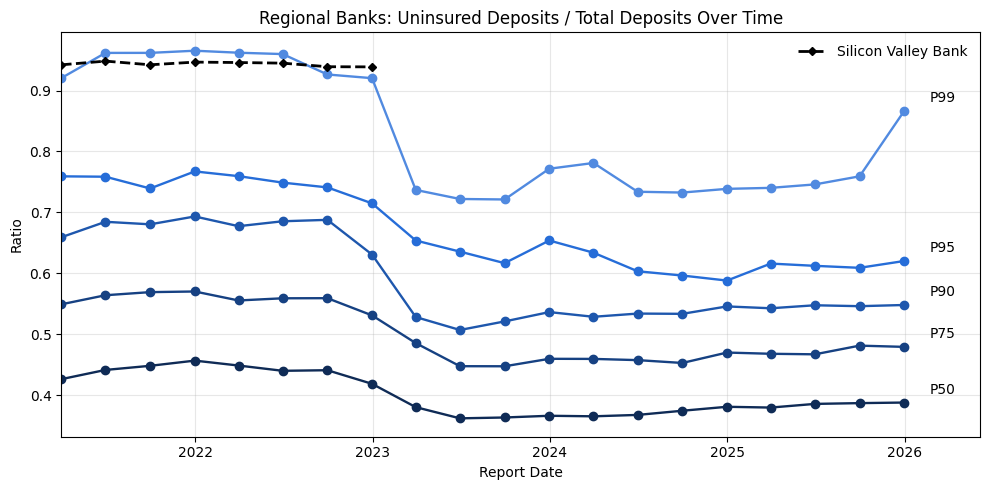

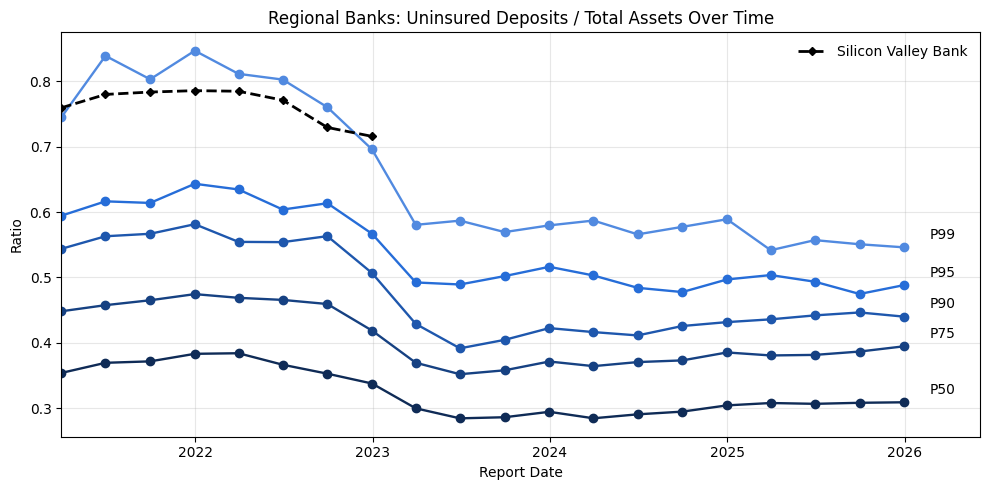

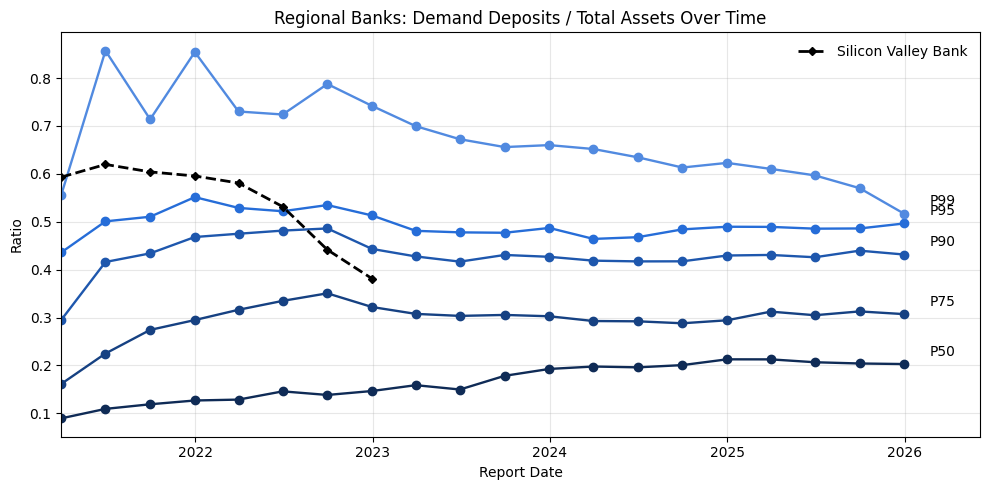

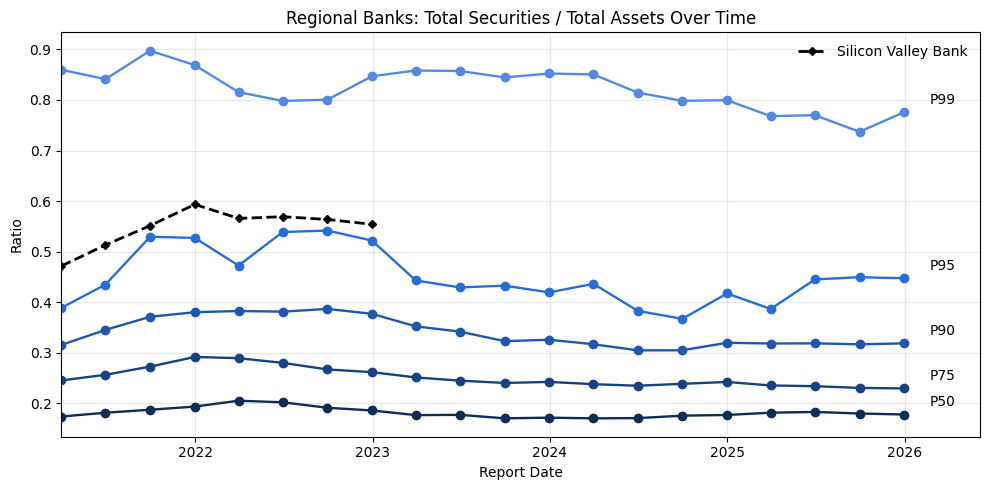

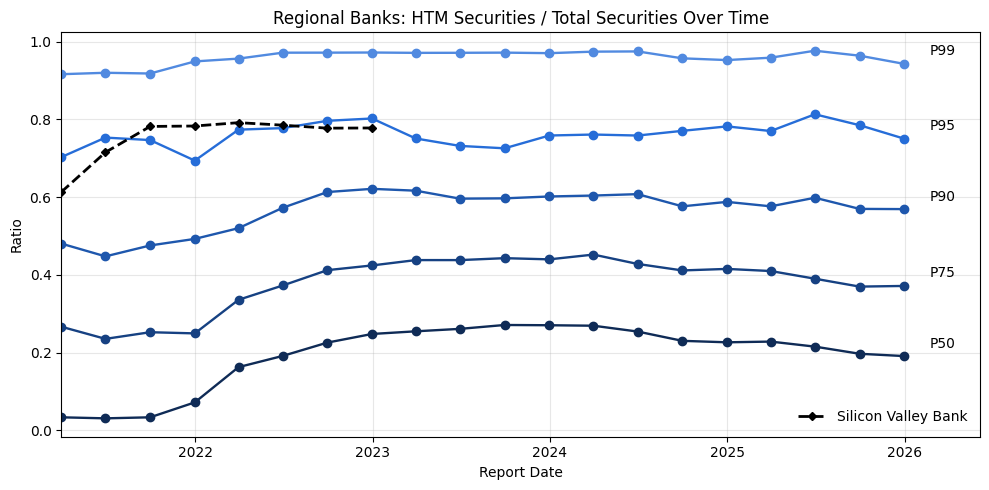

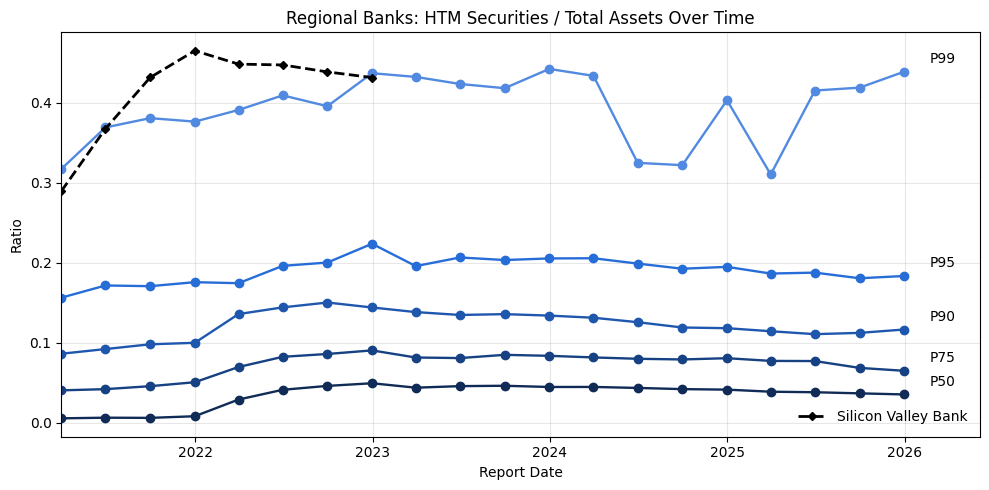

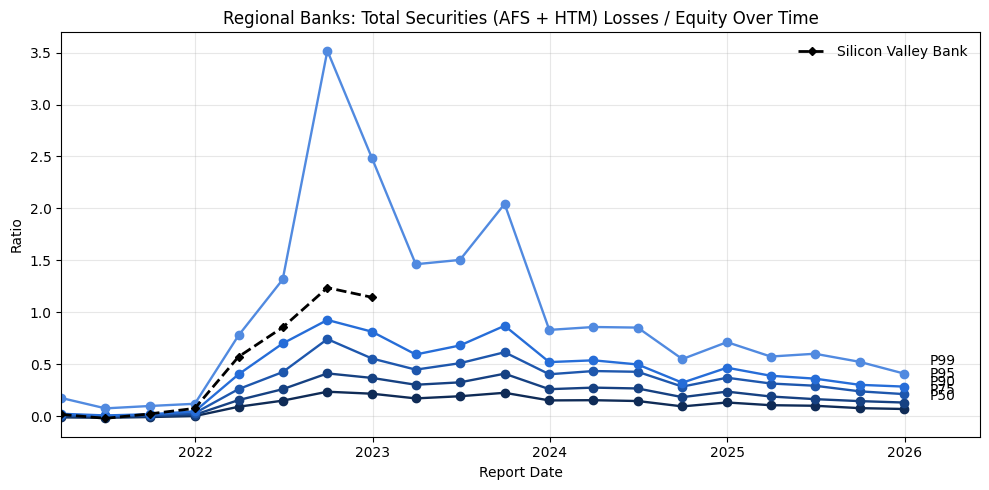

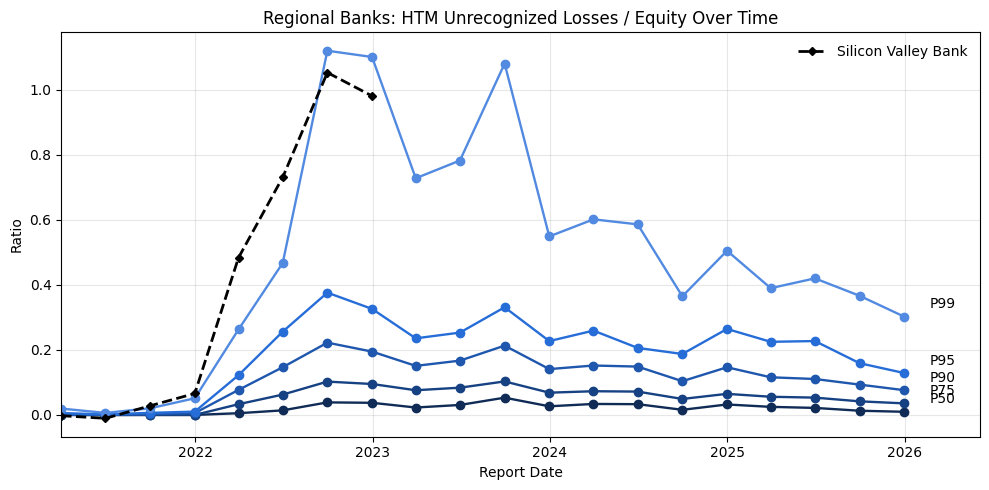

In [ ]:
import colorsys

def regional_bank_mask(
    df,
    min_assets_usd=REGIONAL_MIN_ASSETS_USD,
    max_assets_usd=REGIONAL_MAX_ASSETS_USD,
    assets_col='total_assets',
    asset_scale=ASSET_SCALE,
):
    min_units = min_assets_usd / asset_scale
    max_units = max_assets_usd / asset_scale
    assets = pd.to_numeric(df[assets_col], errors='coerce')
    return (assets > min_units) & (assets < max_units)


def compute_panel_percentiles(panel_df, ratio_cols, group_name='all_banks', group_filter_fn=None):
    rows = []

    for dt, qdf in panel_df.groupby('report_date', sort=True):
        if group_filter_fn is not None:
            mask = group_filter_fn(qdf)
            qdf = qdf.loc[mask]

        pct = compute_percentiles(qdf, ratio_cols)
        pct['report_date'] = dt
        pct['group'] = group_name
        rows.append(pct)

    if not rows:
        return pd.DataFrame(columns=['group', 'report_date', 'ratio', 'n_nonnull', 'p50', 'p75', 'p90', 'p95', 'p99'])

    out = pd.concat(rows, ignore_index=True)
    out = out[['group', 'report_date', 'ratio', 'n_nonnull', 'p50', 'p75', 'p90', 'p95', 'p99']]
    return out.sort_values(['group', 'report_date', 'ratio']).reset_index(drop=True)


def build_quarter_counts(panel_df, regional_mask_full):
    tmp = panel_df[['report_date', 'IDRSSD']].copy()
    tmp['is_regional'] = regional_mask_full.values

    counts = tmp.groupby('report_date').agg(
        total_banks=('IDRSSD', 'nunique'),
        regional_banks=('is_regional', 'sum'),
    ).reset_index()

    counts['regional_banks'] = counts['regional_banks'].astype(int)
    return counts.sort_values('report_date').reset_index(drop=True)


def _ratio_label(ratio_name):
    custom = {
        'uninsured_dep_to_total_dep': 'Uninsured Deposits / Total Deposits',
        'uninsured_dep_to_assets': 'Uninsured Deposits / Total Assets',
        'demand_dep_to_assets': 'Demand Deposits / Total Assets',
        'total_securities_to_assets': 'Total Securities / Total Assets',
        'htm_to_total_securities': 'HTM Securities / Total Securities',
        'htm_to_assets': 'HTM Securities / Total Assets',
        'total_ac_minus_fv_to_equity': 'Total Securities (AFS + HTM) Losses / Equity',
        'htm_ac_minus_fv_to_equity': 'HTM Unrecognized Losses / Equity',

        # Commented (optional reactivation)
        'large_time_deposits_to_total_dep': 'Large Time Deposits (> $250K) / Total Deposits',
        'transaction_dep_to_assets': 'Transaction Deposits / Total Assets',
        'brokered_deposits_to_assets': 'Brokered Deposits / Total Assets',
        'fhlb_advances_to_assets': 'FHLB Advances / Total Assets',
        'repos_to_assets': 'Repurchase Agreements / Total Assets',
        'fed_funds_purchased_to_assets': 'Fed Funds Purchased / Total Assets',
    }
    return custom.get(ratio_name, ratio_name.replace('_', ' ').title())


def _group_label(group_name):
    labels = {
        'regional_banks': 'Regional Banks',
        'all_banks': 'All Banks',
    }
    return labels.get(group_name, group_name.replace('_', ' ').title())


def _list_local_quarter_zips(zip_folder=DATA_RAW_DIR, start_date=DOWNLOAD_START_DATE):
    zip_folder = Path(zip_folder)
    if not zip_folder.exists():
        return pd.DataFrame(columns=['report_date', 'zip_path'])

    rows = []
    for z in sorted(zip_folder.glob('ffiec_call_bulk_all_schedules_*.zip')):
        try:
            dt = _extract_report_date_from_zip_name(z)
        except Exception:
            continue
        if dt >= pd.to_datetime(start_date):
            rows.append({'report_date': dt, 'zip_path': str(z)})

    if not rows:
        return pd.DataFrame(columns=['report_date', 'zip_path'])
    return pd.DataFrame(rows).sort_values('report_date').reset_index(drop=True)


def _is_panel_cache_fresh(panel_parquet_path, local_zip_df):
    panel_parquet_path = Path(panel_parquet_path)
    if not panel_parquet_path.exists() or local_zip_df.empty:
        return False, None, None

    try:
        cached = pd.read_parquet(panel_parquet_path, columns=['report_date'])
        if cached.empty:
            return False, None, None
        cached_latest = pd.to_datetime(cached['report_date']).max()
        local_latest = pd.to_datetime(local_zip_df['report_date']).max()
        is_fresh = cached_latest >= local_latest
        return bool(is_fresh), cached_latest, local_latest
    except Exception:
        return False, None, None


def _code_variants_from_selected(mapping_log_df, concept, fallback_codes=None):
    fallback_codes = fallback_codes or []
    codes = []

    if isinstance(mapping_log_df, pd.DataFrame) and not mapping_log_df.empty and 'concept' in mapping_log_df.columns:
        sub = mapping_log_df.loc[mapping_log_df['concept'] == concept, 'selected_code'].dropna().astype(str)
        codes.extend(sub.tolist())

    codes.extend(fallback_codes)

    out = []
    seen = set()
    for c in codes:
        c = str(c).strip().upper()
        if not c:
            continue

        variants = [c]
        if len(c) >= 8 and c.startswith('RC'):
            suffix = c[4:]
            variants.extend([f'RCON{suffix}', f'RCFD{suffix}', f'RCFN{suffix}', f'RCOA{suffix}'])

        for v in variants:
            if v not in seen:
                out.append(v)
                seen.add(v)

    return out


def _xbrl_report_date_from_filename(path):
    m = re.search(r'_(\d{2})(\d{2})(\d{4})\.XBRL$', Path(path).name, flags=re.IGNORECASE)
    if not m:
        raise ValueError(f'Could not infer date from XBRL filename: {path}')
    mm, dd, yyyy = m.group(1), m.group(2), m.group(3)
    return pd.to_datetime(f'{yyyy}-{mm}-{dd}')


def _parse_xbrl_facts(xbrl_path, wanted_codes):
    wanted_codes = set(wanted_codes)
    facts = {}

    root = ET.parse(xbrl_path).getroot()
    for elem in root.iter():
        tag = elem.tag.split('}')[-1]
        if tag not in wanted_codes:
            continue

        txt = elem.text
        if txt is None:
            continue

        txt = txt.strip().replace(',', '')
        if txt == '':
            continue

        try:
            val = float(txt)
        except Exception:
            continue

        cref = elem.attrib.get('contextRef')
        facts.setdefault(tag, []).append((cref, val))

    return facts


def _pick_preferred_fact(facts_for_code, prefer_prefixes=('CI_', 'CD_')):
    if not facts_for_code:
        return np.nan

    for pref in prefer_prefixes:
        for cref, val in facts_for_code:
            if cref and str(cref).startswith(pref):
                return val

    return facts_for_code[0][1]


def load_svb_xbrl_series(mapping_log_df, xbrl_dir=SVB_CALL_REPORT_DIR, pattern=SVB_XBRL_PATTERN):
    xbrl_dir = Path(xbrl_dir)
    if not xbrl_dir.exists():
        raise FileNotFoundError(f'SVB call report folder not found: {xbrl_dir}')

    files = sorted(xbrl_dir.glob(pattern))
    if not files:
        raise FileNotFoundError(f'No SVB XBRL files found under {xbrl_dir} matching {pattern}')

    concept_codes = {
        'total_deposits': _code_variants_from_selected(mapping_log_df, 'total_deposits', ['RCON2200', 'RCFD2200']),
        'uninsured_deposits': _code_variants_from_selected(mapping_log_df, 'uninsured_deposits', ['RCON5597', 'RCFD5597']),
        'total_equity_capital': _code_variants_from_selected(mapping_log_df, 'total_equity_capital', ['RCON3210', 'RCFD3210']),
        'large_time_deposits_gt_250k': _code_variants_from_selected(mapping_log_df, 'large_time_deposits_gt_250k', []),
    }

    wanted_codes = sorted({code for codes in concept_codes.values() for code in codes})
    rows = []

    for fp in files:
        facts = _parse_xbrl_facts(fp, wanted_codes)
        row = {'report_date': _xbrl_report_date_from_filename(fp), 'xbrl_file': fp.name}

        for concept, codes in concept_codes.items():
            val = np.nan
            used_code = None
            for code in codes:
                if code in facts:
                    val = _pick_preferred_fact(facts[code])
                    used_code = code
                    break
            row[concept] = val
            row[f'{concept}__code'] = used_code

        rows.append(row)

    out = pd.DataFrame(rows).sort_values('report_date').reset_index(drop=True)
    out['report_date'] = pd.to_datetime(out['report_date'])
    return out


def _infer_xbrl_to_bs_scale(bs_df, xbrl_df):
    chk = bs_df[['report_date', 'TotalDeposits']].merge(
        xbrl_df[['report_date', 'total_deposits']], on='report_date', how='inner'
    )

    chk['TotalDeposits'] = pd.to_numeric(chk['TotalDeposits'], errors='coerce')
    chk['total_deposits'] = pd.to_numeric(chk['total_deposits'], errors='coerce')

    valid = chk[(chk['TotalDeposits'] > 0) & (chk['total_deposits'] > 0)]
    if valid.empty:
        return 1.0, 'insufficient overlap for scaling check (defaulted to 1.0)'

    med_ratio = float((valid['TotalDeposits'] / valid['total_deposits']).median())

    if 0.0000005 <= med_ratio <= 0.0000015:
        return 0.000001, 'xbrl values appear in dollars; scaled to millions (x0.000001)'
    if 0.0005 <= med_ratio <= 0.0015:
        return 0.001, 'xbrl values appear in thousands; scaled to millions (x0.001)'
    if 0.5 <= med_ratio <= 2.0:
        return 1.0, 'xbrl and BS values appear on same unit scale'

    return med_ratio, f'xbrl scaled by median overlap ratio ({med_ratio:.6g})'


def build_svb_ratio_overlay(mapping_log_df, ratio_cols, bs_path=SVB_BS_PATH, xbrl_dir=SVB_CALL_REPORT_DIR):
    bs_path = Path(bs_path)
    if not bs_path.exists():
        raise FileNotFoundError(f'SVB balance-sheet file not found: {bs_path}')

    bs = pd.read_excel(bs_path, skiprows=[0, 1])
    required_cols = {
        'Dates': 'report_date',
        'BS_TOT_ASSET': 'TotalAssets',
        'BS_CUSTOMER_DEPOSITS': 'TotalDeposits',
        'BS_DEMAND_DPST': 'DemandDeposits',
        'FDIC_SECS_HELD_TO_MTY_BOOK_VAL': 'HTM_BV',
        'FDIC_SECS_AVAIL_FOR_SALE_MKT_VAL': 'AFS_FV',
        'FED_TOTAL_SECURITIES_HTM_FV': 'HTM_FV',
        'FED_TOTAL_SECURITIES_AFS_COST': 'AFS_BV',
    }

    missing_bs = [c for c in required_cols if c not in bs.columns]
    if missing_bs:
        raise ValueError(f'SVB_BS_Data.xlsx missing required columns: {missing_bs}')

    bs = bs[list(required_cols.keys())].rename(columns=required_cols)
    bs['report_date'] = pd.to_datetime(bs['report_date']).dt.normalize()

    for col in ['TotalAssets', 'TotalDeposits', 'DemandDeposits', 'HTM_BV', 'AFS_FV', 'HTM_FV', 'AFS_BV']:
        bs[col] = pd.to_numeric(bs[col], errors='coerce')

    xbrl = load_svb_xbrl_series(mapping_log_df, xbrl_dir=xbrl_dir)
    scale_factor, scale_note = _infer_xbrl_to_bs_scale(bs, xbrl)

    xbrl_scaled = xbrl.copy()
    xbrl_numeric_cols = [
        c for c in xbrl_scaled.columns
        if c not in {'report_date', 'xbrl_file'} and not c.endswith('__code')
    ]
    for c in xbrl_numeric_cols:
        xbrl_scaled[c] = pd.to_numeric(xbrl_scaled[c], errors='coerce') * scale_factor

    svb = bs.merge(xbrl_scaled, on='report_date', how='left')
    svb = svb.sort_values('report_date').reset_index(drop=True)

    ratio_input = pd.DataFrame({
        'report_date': svb['report_date'],
        'total_assets': svb['TotalAssets'],
        'total_deposits': svb['total_deposits'].combine_first(svb['TotalDeposits']),
        'uninsured_deposits': svb['uninsured_deposits'],
        'demand_deposits': svb['DemandDeposits'],
        'htm_securities': svb['HTM_BV'],
        'afs_securities': svb['AFS_FV'],
        'afs_amortized_cost': svb['AFS_BV'],
        'htm_fair_value': svb['HTM_FV'],
        'total_equity_capital': svb['total_equity_capital'],
        'large_time_deposits_gt_250k': svb['large_time_deposits_gt_250k'],
    })

    # Add placeholders for optional funding columns expected by compute_ratios helper logic.
    for c in ['fhlb_advances_le_1y', 'fhlb_advances_1_3y', 'fhlb_advances_3_5y', 'fhlb_advances_gt_5y']:
        ratio_input[c] = np.nan

    ratio_input = compute_ratios(ratio_input)
    ratio_input['bank_name'] = 'Silicon Valley Bank'

    keep_cols = ['report_date', 'bank_name'] + [c for c in ratio_cols if c in ratio_input.columns]
    ratio_out = ratio_input[keep_cols].copy()

    meta = {
        'scale_factor_xbrl_to_bs': scale_factor,
        'scale_note': scale_note,
        'n_points': int(ratio_out['report_date'].nunique()),
    }

    return ratio_out, meta


def plot_percentile_timeseries(
    percentile_df,
    ratio,
    group='regional_banks',
    percentile_cols=('p50', 'p75', 'p90', 'p95', 'p99'),
    overlay_df=None,
    overlay_label='SVB',
):
    # Keep hue/saturation fixed (blue); vary only lightness (HLS) so the scale moves on one axis.
    blue_h = 0.6  # ~blue in H (0..1)
    sat = 0.7
    lights = {
        'p50': 0.2,
        'p75': 0.3,
        'p90': 0.4,
        'p95': 0.5,
        'p99': 0.6
    }

    palette = {}
    for k, l in lights.items():
        r, g, b = colorsys.hls_to_rgb(blue_h, l, sat)
        palette[k] = '#{0:02x}{1:02x}{2:02x}'.format(int(r * 255), int(g * 255), int(b * 255))

    sub = percentile_df[(percentile_df['ratio'] == ratio) & (percentile_df['group'] == group)].copy()
    if sub.empty:
        print(f'No data to plot for ratio={ratio}, group={group}')
        return

    sub = sub.sort_values('report_date')
    plt.figure(figsize=(10, 5))

    plotted_lines = []
    y_pool = []

    for c in percentile_cols:
        if c in sub.columns:
            y = pd.to_numeric(sub[c], errors='coerce')
            line, = plt.plot(
                sub['report_date'],
                y,
                marker='o',
                linewidth=1.7,
                color=palette.get(c, None),
            )
            plotted_lines.append((c.upper(), line, y))
            y_pool.extend(y.dropna().tolist())

    overlay_end = None
    if isinstance(overlay_df, pd.DataFrame) and (ratio in overlay_df.columns):
        ov = overlay_df[['report_date', ratio]].copy()
        ov['report_date'] = pd.to_datetime(ov['report_date'])
        ov[ratio] = pd.to_numeric(ov[ratio], errors='coerce')
        ov = ov.dropna().sort_values('report_date')

        if not ov.empty:
            plt.plot(
                ov['report_date'],
                ov[ratio],
                color='black',
                linestyle='--',
                marker='D',
                linewidth=2.0,
                markersize=4,
                label='Silicon Valley Bank',
            )
            overlay_end = (ov['report_date'].iloc[-1], ov[ratio].iloc[-1])
            y_pool.extend(ov[ratio].dropna().tolist())

    title = f"{_group_label(group)}: {_ratio_label(ratio)} Over Time"
    plt.title(title)
    plt.xlabel('Report Date')
    plt.ylabel('Ratio')
    plt.grid(alpha=0.3)

    # Direct labels on the line ends (replaces percentile legend).
    if y_pool:
        y_min = min(y_pool)
        y_max = max(y_pool)
        y_span = y_max - y_min
        if not np.isfinite(y_span) or y_span <= 0:
            y_span = max(abs(y_max), 1.0)
        y_offset = 0.015 * y_span
    else:
        y_offset = 0.01

    x_series = pd.to_datetime(sub['report_date'])
    x_min = x_series.min()
    x_max = x_series.max()
    x_span_days = max(int((x_max - x_min).days), 1)
    label_dx = pd.Timedelta(days=max(8, int(0.03 * x_span_days)))

    for txt, line, y in plotted_lines:
        y_valid = y.dropna()
        if y_valid.empty:
            continue
        x_last = x_series.loc[y_valid.index[-1]]
        y_last = y_valid.iloc[-1]
        plt.text(
            x_last + label_dx,
            y_last + y_offset,
            txt,
            color='black',
            fontsize=10,
            fontweight='normal',
            va='bottom',
            ha='left',
        )

    # Extend right-side room so end labels are visible.
    plt.xlim(x_min, x_max + label_dx * 3)

    if overlay_end is not None:
        plt.legend(loc='best', frameon=False)

    plt.tight_layout()
    plt.show()


# Build panel from downloaded zips (or pre-existing zips in DATA_RAW_DIR)
if not DATA_RAW_DIR.exists():
    DATA_RAW_DIR.mkdir(parents=True, exist_ok=True)

# Convenience fallback for local testing if only the single sample zip exists in notebook folder
fallback_zip = Path(ZIP_FILENAME)
if fallback_zip.exists() and not list(DATA_RAW_DIR.glob('ffiec_call_bulk_all_schedules_*.zip')):
    inferred_date = _extract_report_date_from_zip_name(fallback_zip)
    fallback_target = DATA_RAW_DIR / f'ffiec_call_bulk_all_schedules_{inferred_date.strftime("%Y%m%d")}.zip'
    if not fallback_target.exists():
        fallback_target.write_bytes(fallback_zip.read_bytes())
        print(f'Copied fallback zip into {fallback_target}')

# Optional remote refresh (only if user enables it)
if RUN_BULK_DOWNLOAD:
    discovered_periods_df, download_log_df = download_ffiec_bulk_history(
        out_dir=DATA_RAW_DIR,
        start_date=DOWNLOAD_START_DATE,
    )
    print(f'Download step complete. Rows in log: {len(download_log_df)}')

local_zip_df = _list_local_quarter_zips(DATA_RAW_DIR, DOWNLOAD_START_DATE)
if local_zip_df.empty:
    raise FileNotFoundError('No quarter zip files found in data_raw_ffiec/.')

panel_parquet_path = DATA_PROCESSED_DIR / 'ffiec_panel_2021_latest.parquet'
use_cache = False
cache_fresh, cached_latest, local_latest = _is_panel_cache_fresh(panel_parquet_path, local_zip_df)

if USE_CACHED_PANEL_IF_FRESH and (not FORCE_REBUILD_PANEL) and cache_fresh:
    use_cache = True

if use_cache:
    print(f'Using cached panel from {panel_parquet_path}')
    print(f'Cached latest quarter: {cached_latest.date()} | Local latest zip quarter: {local_latest.date()}')
    panel_df = pd.read_parquet(panel_parquet_path)
    panel_df['report_date'] = pd.to_datetime(panel_df['report_date'])

    # Recompute ratios in case new derived metrics were added since cache creation.
    panel_df = compute_ratios(panel_df)

    mapping_log_path = DATA_PROCESSED_DIR / 'ffiec_mapping_log_by_quarter.csv'
    used_codes_path = DATA_PROCESSED_DIR / 'ffiec_used_codes_by_quarter.csv'
    mapping_changes_path = DATA_PROCESSED_DIR / 'ffiec_mapping_changes_vs_reference.csv'

    mapping_log_df = pd.read_csv(mapping_log_path) if mapping_log_path.exists() else pd.DataFrame()
    used_code_log_df = pd.read_csv(used_codes_path) if used_codes_path.exists() else pd.DataFrame()
    mapping_changes_df = pd.read_csv(mapping_changes_path) if mapping_changes_path.exists() else pd.DataFrame()
else:
    print('Cache missing/stale or rebuild forced -> rebuilding panel from raw quarter zips...')
    panel_df, mapping_log_df, used_code_log_df, mapping_changes_df = build_panel_dataset(
        zip_folder=DATA_RAW_DIR,
        start_date=DOWNLOAD_START_DATE,
    )

# Ratios for time-series summary (active + commented options)
ratio_cols_ts = [
    'uninsured_dep_to_total_dep',
    'uninsured_dep_to_assets',
    'demand_dep_to_assets',
    'total_securities_to_assets',
    'htm_to_total_securities',
    'htm_to_assets',
    'total_ac_minus_fv_to_equity',
    'htm_ac_minus_fv_to_equity',

    # Commented (optional reactivation)
    # 'large_time_deposits_to_total_dep',
    # 'transaction_dep_to_assets',
    # 'brokered_deposits_to_assets',
    # 'fhlb_advances_to_assets',
    # 'repos_to_assets',
    # 'fed_funds_purchased_to_assets',
]
ratio_cols_ts = [c for c in ratio_cols_ts if c in panel_df.columns]

regional_mask_full = regional_bank_mask(panel_df)

percentiles_all = compute_panel_percentiles(
    panel_df,
    ratio_cols_ts,
    group_name='all_banks',
    group_filter_fn=None,
)

percentiles_regional = compute_panel_percentiles(
    panel_df,
    ratio_cols_ts,
    group_name='regional_banks',
    group_filter_fn=lambda d: regional_bank_mask(d),
)

percentiles_panel = pd.concat([percentiles_all, percentiles_regional], ignore_index=True)

quarter_counts = build_quarter_counts(panel_df, regional_mask_full)

latest_date = panel_df['report_date'].max()
latest_regional_top10 = (
    panel_df.loc[(panel_df['report_date'] == latest_date) & regional_mask_full, [
        c for c in [
            'Financial Institution Name',
            'IDRSSD',
            'FDIC Certificate Number',
            'total_assets',
            'total_deposits',
            'uninsured_deposits',
            'uninsured_dep_to_total_dep',
        ] if c in panel_df.columns
    ]]
    .sort_values('uninsured_dep_to_total_dep', ascending=False)
    .head(10)
)

# Build SVB overlay series for the selected active ratios.
svb_ratio_df = pd.DataFrame(columns=['report_date'])
svb_overlay_meta = {}

if PLOT_SVB_OVERLAY:
    try:
        svb_ratio_df, svb_overlay_meta = build_svb_ratio_overlay(
            mapping_log_df=mapping_log_df,
            ratio_cols=ratio_cols_ts,
            bs_path=SVB_BS_PATH,
            xbrl_dir=SVB_CALL_REPORT_DIR,
        )

        svb_ratio_df = svb_ratio_df[
            (pd.to_datetime(svb_ratio_df['report_date']) >= panel_df['report_date'].min())
            & (pd.to_datetime(svb_ratio_df['report_date']) <= panel_df['report_date'].max())
        ].copy()
        svb_overlay_meta['n_points_in_panel_window'] = int(svb_ratio_df['report_date'].nunique())

        svb_available = [
            c for c in ratio_cols_ts
            if c in svb_ratio_df.columns and pd.to_numeric(svb_ratio_df[c], errors='coerce').notna().any()
        ]
        svb_missing = [c for c in ratio_cols_ts if c not in svb_available]

        print(
            f"SVB overlay points in panel window: {svb_overlay_meta.get('n_points_in_panel_window', 0)} "
            f"| scale: {svb_overlay_meta.get('scale_factor_xbrl_to_bs', np.nan)} "
            f"| note: {svb_overlay_meta.get('scale_note', '')}"
        )
        if svb_missing:
            print('SVB overlay unavailable for:', ', '.join(svb_missing))
    except Exception as e:
        warnings.warn(f'Could not build SVB overlay series: {e}', RuntimeWarning)

print(f'Panel rows: {len(panel_df):,}')
print(f'Unique quarters: {panel_df["report_date"].nunique()}')
print(f'Latest quarter: {latest_date.date()}')
print(f'Ratios plotted: {len(ratio_cols_ts)}')

print('\nQuarter counts:')
display(quarter_counts)

print('\nPercentiles panel sample:')
display(percentiles_panel.head(20))

if not mapping_changes_df.empty:
    print('\nWARNING: mapping changes detected vs reference quarter:')
    display(mapping_changes_df)

print('\nTop 10 regional banks by uninsured deposit ratio in latest quarter:')
display(latest_regional_top10)

# Time-series plots: plot all available selected ratios for regional banks
for ratio_name in ratio_cols_ts:
    plot_percentile_timeseries(
        percentiles_panel,
        ratio_name,
        group='regional_banks',
        overlay_df=svb_ratio_df,
        overlay_label='SVB',
    )


## Phase 6: Outputs
- panel parquet (`data_processed/ffiec_panel_2021_latest.parquet`)
- percentile CSVs
- counts and latest-quarter top10 CSV
- mapping logs

In [63]:
if EXPORT_OUTPUTS:
    DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

    panel_parquet_path = DATA_PROCESSED_DIR / 'ffiec_panel_2021_latest.parquet'
    pct_all_csv_path = DATA_PROCESSED_DIR / 'ffiec_percentiles_all_banks_2021_latest.csv'
    pct_reg_csv_path = DATA_PROCESSED_DIR / 'ffiec_percentiles_regional_banks_2021_latest.csv'
    pct_panel_csv_path = DATA_PROCESSED_DIR / 'ffiec_percentiles_panel_2021_latest.csv'
    counts_csv_path = DATA_PROCESSED_DIR / 'ffiec_quarter_bank_counts_2021_latest.csv'
    top10_csv_path = DATA_PROCESSED_DIR / 'ffiec_top10_regional_uninsured_latest_quarter.csv'
    mapping_log_csv_path = DATA_PROCESSED_DIR / 'ffiec_mapping_log_by_quarter.csv'
    used_codes_csv_path = DATA_PROCESSED_DIR / 'ffiec_used_codes_by_quarter.csv'
    mapping_changes_csv_path = DATA_PROCESSED_DIR / 'ffiec_mapping_changes_vs_reference.csv'
    svb_overlay_csv_path = DATA_PROCESSED_DIR / 'svb_ratio_overlay_timeseries.csv'

    panel_df.to_parquet(panel_parquet_path, index=False)
    percentiles_all.to_csv(pct_all_csv_path, index=False)
    percentiles_regional.to_csv(pct_reg_csv_path, index=False)
    percentiles_panel.to_csv(pct_panel_csv_path, index=False)
    quarter_counts.to_csv(counts_csv_path, index=False)
    latest_regional_top10.to_csv(top10_csv_path, index=False)
    mapping_log_df.to_csv(mapping_log_csv_path, index=False)
    used_code_log_df.to_csv(used_codes_csv_path, index=False)
    mapping_changes_df.to_csv(mapping_changes_csv_path, index=False)

    if 'svb_ratio_df' in globals() and isinstance(svb_ratio_df, pd.DataFrame) and (not svb_ratio_df.empty):
        svb_ratio_df.to_csv(svb_overlay_csv_path, index=False)

    print(f'Wrote: {panel_parquet_path}')
    print(f'Wrote: {pct_panel_csv_path}')
    print(f'Wrote: {counts_csv_path}')
    print(f'Wrote: {top10_csv_path}')
    if 'svb_ratio_df' in globals() and isinstance(svb_ratio_df, pd.DataFrame) and (not svb_ratio_df.empty):
        print(f'Wrote: {svb_overlay_csv_path}')


Wrote: 2. Data\Processed\ffiec_panel_2021_latest.parquet
Wrote: 2. Data\Processed\ffiec_percentiles_panel_2021_latest.csv
Wrote: 2. Data\Processed\ffiec_quarter_bank_counts_2021_latest.csv
Wrote: 2. Data\Processed\ffiec_top10_regional_uninsured_latest_quarter.csv
Wrote: 2. Data\Processed\svb_ratio_overlay_timeseries.csv
